In [24]:
# 1. Importy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

# 2. Wczytanie danych z CSV
df = pd.read_csv('C:\ML-danych-pogodowych\data\pogodynka_zbilansowana.csv')

# 3. Konwersja zmiennych problematycznych
# Kolumna 'ZjawiskaPop' — zamień na tekst
df['ZjawiskaPop'] = df['ZjawiskaPop'].astype(str)
# Kolumna 'godzina' — wyciągnij liczbę i zamień na float
df['godzina'] = df['godzina'].astype(str).str.extract(r'(\d+)')
df['godzina'] = pd.to_numeric(df['godzina'], errors='coerce')

In [25]:
# 4. Wypełnij brakujące wartości (nie usuwamy wierszy!)
df = df.fillna(df.median(numeric_only=True))

# 5. Wybór zmiennych (cechy + target)
feature_cols = ['WysokoscPodstChmur', 'Widzialnosc', 'WielkoscZachmurzenia', 
                'TemperaturaPowietrza', 'DeficytPktRosy', 'Deltatemp', 'DeltaRosy', 
                'CisnienieNaPoziomieMorza', 'WielkoscTendencjiCisnienia', 
                'godzina']  # możesz dodać więcej

X = df[feature_cols]
y = df['Opad']

In [32]:
df = df.drop(columns=["ZjawiskaPop", "Kategoria"], errors="ignore")

# 6.1. Tworzenie nowej kolumny z kategorią opadu
def opad_kategoria(x):
    if x == 0:
        return 0  # brak opadu
    elif x < 1:
        return 1  # słaby opad
    elif x < 3:
        return 2  # średni opad
    else:
        return 3  # silny opad

df['Opad_kat'] = df['Opad'].apply(opad_kategoria)

# 6.2. Wybór cech i celu
X = df.drop(columns=['Opad', 'Opad_kat'])  # X: wszystkie inne kolumny (oprócz 'Opad' i 'Opad_kat')
y = df['Opad_kat']                         # y: kolumna z kategorią opadu


In [33]:
from sklearn.model_selection import train_test_split

# 7. Podział danych na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [34]:
import xgboost as xgb

# 8. Trening modelu XGBoost
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
model.fit(X_train, y_train)


C:\Users\Rafal Karpowicz\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:51:35] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 9. Predykcja
y_pred = model.predict(X_test)

# 10. Ocena
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8687604410290678

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92     11122
           1       0.79      0.65      0.71      3680
           2       0.84      0.45      0.59       152
           3       1.00      0.36      0.53        11

    accuracy                           0.87     14965
   macro avg       0.88      0.60      0.69     14965
weighted avg       0.86      0.87      0.86     14965


Confusion Matrix:
 [[10527   590     5     0]
 [ 1274  2401     5     0]
 [   30    53    69     0]
 [    2     2     3     4]]


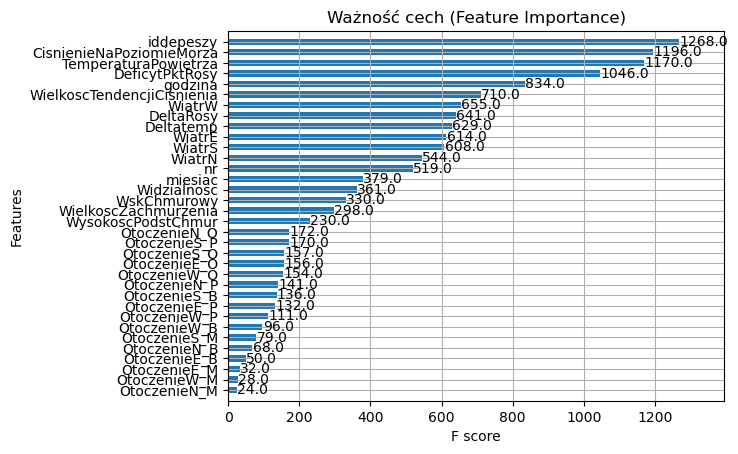

In [36]:
# 11. Wykres ważności cech
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model, height=0.6)
plt.title("Ważność cech (Feature Importance)")
plt.show()


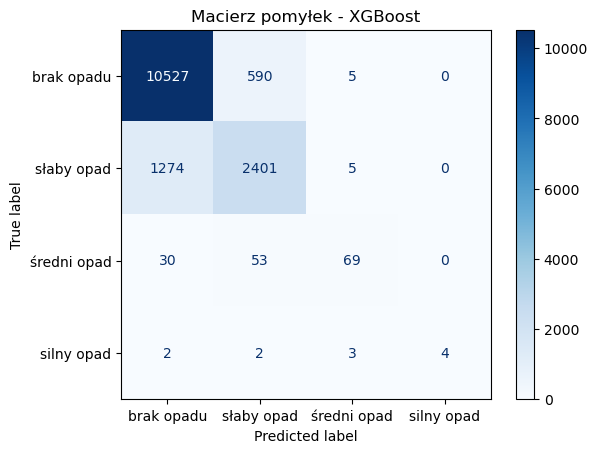

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

# Tworzymy obiekt ConfusionMatrixDisplay i rysujemy go
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["brak opadu", "słaby opad", "średni opad", "silny opad"],
    cmap='Blues',
    values_format='d'  # liczby całkowite
)
plt.title("Macierz pomyłek - XGBoost")
plt.grid(False)
plt.show()
